In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
data = pd.read_csv(r"C:\Users\manju\OneDrive\Desktop\Documents\Data Analytics\DA Semester 4\Capstone 2\ML Modelling\ml_dataset.csv")
data.head().T

,0,1,2,3,4
year,2012,2012,2012,2012,2012
state_code,NY,IN,SC,IN,AL
provider_type,General Short-Term (includes CAH),General Short-Term (includes CAH),Psychiatric Hospital,Psychiatric Hospital,General Short-Term (includes CAH)
ccn_facility_type,Short-Term Hospital,Short-Term Hospital,Psychiatric Hospital,Psychiatric Hospital,Short-Term Hospital
number_of_beds,66.0,66.0,66.0,66.0,25.0
total_bed_days_available,23424.0,23424.0,23424.0,23424.0,2196.0
occupancy_rate,0.519244,0.519244,0.519244,0.519244,0.147692
total_discharges__v___xviii___xix___unknown_,1659.0,1659.0,1659.0,1659.0,62.0
total_days__v___xviii___xix___unknown_,11979.0,11979.0,11979.0,11979.0,288.0
fte___employees_on_payroll,295.42,295.42,295.42,295.42,52.5


In [9]:
# Dataset Information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69555 entries, 0 to 69554
Data columns (total 51 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   year                                          69555 non-null  int64  
 1   state_code                                    69555 non-null  object 
 2   provider_type                                 69555 non-null  object 
 3   ccn_facility_type                             69555 non-null  object 
 4   number_of_beds                                69555 non-null  float64
 5   total_bed_days_available                      69555 non-null  float64
 6   occupancy_rate                                69555 non-null  float64
 7   total_discharges__v___xviii___xix___unknown_  69555 non-null  float64
 8   total_days__v___xviii___xix___unknown_        69555 non-null  float64
 9   fte___employees_on_payroll                    69555 non-null 

### Profit Margin Feature Selection using Sequential Feature Selector

This code performs feature selection for predicting 'Profit Margin' using a `RandomForestRegressor` in conjunction with `SequentialFeatureSelector` from `sklearn.feature_selection`. The process involves:

1.  **Initializing `RandomForestRegressor`**: A Random Forest model is set up for regression tasks.
2.  **Sequential Feature Selection (SFS)**: A forward sequential feature selection strategy is applied to select the top 15 features that maximize the R2 score, using 3-fold cross-validation.
3.  **Identifying Selected Features**: The column names of the selected features are extracted.
4.  **Creating New Datasets**: Training and testing datasets are created using only the selected features.
5.  **Cross-Validation Performance Check**: The performance of the `RandomForestRegressor` is evaluated on the new dataset using 5-fold cross-validation to report R2 scores and their average.

```python
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score


# Profit Margin Feature Selection

rf_pm = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

# Sequential Feature Selection
sfs_pm = SequentialFeatureSelector(
    rf_pm,
    n_features_to_select=15,
    direction='forward',
    scoring='r2',
    cv=3,
    n_jobs=-1
)

sfs_pm.fit(X_pm_train, y_pm_train)

# Selected Features
pm_selected_features = X_pm_train.columns[sfs_pm.get_support()]

print("Selected Profit Margin Features:")
print(list(pm_selected_features))


# Create New Dataset With Selected Features
X_pm_train_selected = X_pm_train[pm_selected_features]
X_pm_test_selected = X_pm_test[pm_selected_features]


# Cross-Validation Performance Check
rf_pm.fit(X_pm_train_selected, y_pm_train)

cv_scores_pm = cross_val_score(
    rf_pm,
    X_pm_train_selected,
    y_pm_train,
    cv=5,
    scoring='r2'
)

print("\nProfit Margin Cross-Validated R2 Scores:", cv_scores_pm)
print("Average CV R2:", round(np.mean(cv_scores_pm), 3))
```

In [10]:
#  Rename Other column to other healthcare wages
data.rename(columns={'Other': 'other_healthcare_occupations_wages'}, inplace=True)

In [11]:
# Convert categorical columns
categorical_cols = [
    'state_code',
    'provider_type',
    'ccn_facility_type',
    'type_of_control',
    'rural_urban'
]

for col in categorical_cols:
    data[col] = data[col].astype('category')

# FIPS
data['fips'] = data['fips'].astype('int64').astype('str').astype('category')

# Medicare CBSA Number
data['medicare_cbsa_number'] = data['medicare_cbsa_number'].astype('int64').astype('str').astype('category')

# Ensure year is numeric
data['year'] = pd.to_numeric(data['year'], errors='coerce')

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69555 entries, 0 to 69554
Data columns (total 51 columns):
 #   Column                                        Non-Null Count  Dtype   
---  ------                                        --------------  -----   
 0   year                                          69555 non-null  int64   
 1   state_code                                    69555 non-null  category
 2   provider_type                                 69555 non-null  category
 3   ccn_facility_type                             69555 non-null  category
 4   number_of_beds                                69555 non-null  float64 
 5   total_bed_days_available                      69555 non-null  float64 
 6   occupancy_rate                                69555 non-null  float64 
 7   total_discharges__v___xviii___xix___unknown_  69555 non-null  float64 
 8   total_days__v___xviii___xix___unknown_        69555 non-null  float64 
 9   fte___employees_on_payroll                    6955

In [13]:
profit_margin_numeric_features = [
    'cost_to_charge_ratio',
    'debt_to_asset_ratio',
    'fte___employees_on_payroll',
    'net_patient_revenue',
    'number_of_beds',
    'population',
    'rucc_code',
    'total_assets',
    'total_costs',
    'total_current_assets',
    'total_liabilities',
    'total_other_expenses',
    'year'
]

categorical_cols = [
    'provider_type',
    'ccn_facility_type',
    'type_of_control',
    'rural_urban'
]

final_profit_margin_features = profit_margin_numeric_features + categorical_cols

In [14]:
from sklearn.model_selection import train_test_split

X_profit_margin = data[final_profit_margin_features].copy()
y_profit_margin = data['profit_margin_calc']

X_pm_train, X_pm_test, y_pm_train, y_pm_test = train_test_split(X_profit_margin,y_profit_margin,test_size=0.2,random_state=42)

In [15]:
import category_encoders as ce

encoder = ce.OneHotEncoder(cols=categorical_cols,use_cat_names=True)

X_pm_train_encoded = encoder.fit_transform(X_pm_train)
X_pm_test_encoded = encoder.transform(X_pm_test)

In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

rf_model = RandomForestRegressor(n_estimators=300,random_state=42,n_jobs=-1)

rf_model.fit(X_pm_train_encoded, y_pm_train)

y_pm_pred = rf_model.predict(X_pm_test_encoded)

r2 = r2_score(y_pm_test, y_pm_pred)

print("Profit Margin Test R²:", round(r2, 3))

Profit Margin Test R²: 0.517


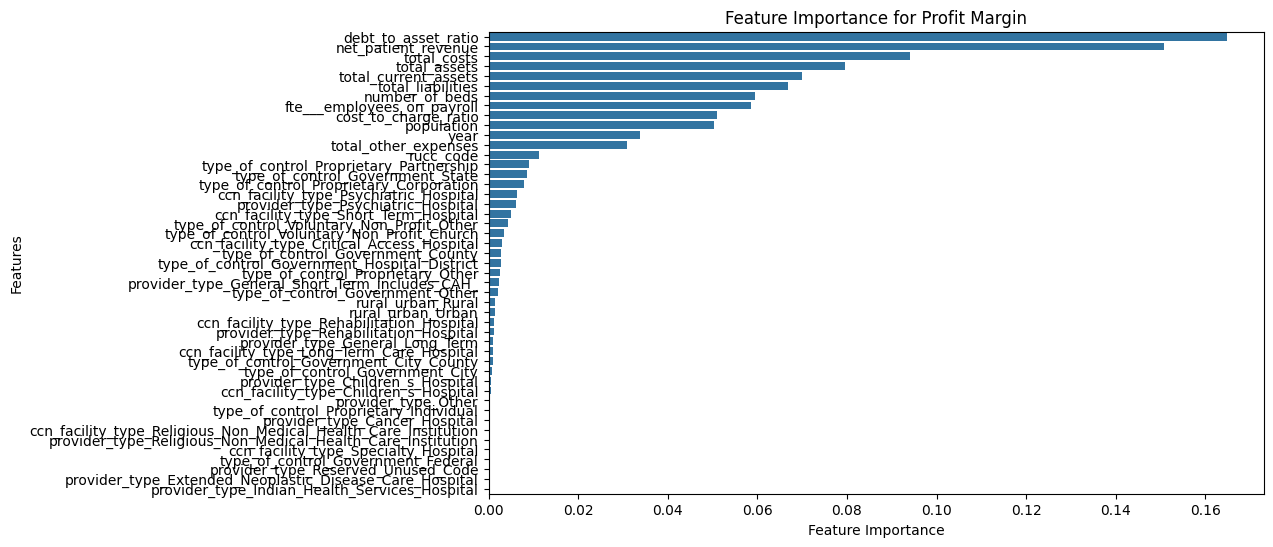

In [38]:
# Feature Importances for Profit Margin
feature_importances = pd.Series(rf_model.feature_importances_, index=X_pm_train_encoded.columns)
feature_importances = feature_importances.sort_values(ascending=False)
# Plot Importances
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_importances.index)
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance for Profit Margin')
plt.show()

In [39]:
feature_importances.head(20)

debt_to_asset_ratio                           0.164734
net_patient_revenue                           0.150668
total_costs                                   0.094171
total_assets                                  0.079587
total_current_assets                          0.070027
total_liabilities                             0.066938
number_of_beds                                0.059532
fte___employees_on_payroll                    0.058577
cost_to_charge_ratio                          0.051075
population                                    0.050386
year                                          0.033828
total_other_expenses                          0.030893
rucc_code                                     0.011252
type_of_control_Proprietary_Partnership       0.008931
type_of_control_Government_State              0.008684
type_of_control_Proprietary_Corporation       0.007942
ccn_facility_type_Psychiatric_Hospital        0.006374
provider_type_Psychiatric_Hospital            0.006212
ccn_facili

### Charity Care Ratio

In [18]:
charity_numeric_features = [
    'year',
    'number_of_beds',
    'total_bed_days_available',
    'total_discharges__v___xviii___xix___unknown_',
    'fte___employees_on_payroll',
    'total_assets',
    'total_liabilities',
    'cost_to_charge_ratio',
    'revenue_per_bed',
    'staff_to_bed_ratio',
    'rucc_code',
    'population',
    'median_age'
]

categorical_cols = [
    'provider_type',
    'ccn_facility_type',
    'type_of_control',
    'rural_urban'
]

final_features_charity = charity_numeric_features + categorical_cols


In [19]:
X_ccr = data[final_features_charity].copy()
y_ccr = data['charity_care_ratio']

from sklearn.model_selection import train_test_split

X_train_ccr, X_test_ccr, y_train_ccr, y_test_ccr = train_test_split(X_ccr, y_ccr, test_size=0.2, random_state=42)

import category_encoders as ce

encoder = ce.OneHotEncoder(cols=categorical_cols, use_cat_names=True)

X_train_ccr_encoded = encoder.fit_transform(X_train_ccr)
X_test_ccr_encoded = encoder.transform(X_test_ccr)

In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

rf_charity = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_charity.fit(X_train_ccr_encoded, y_train_ccr)

y_pred_ccr = rf_charity.predict(X_test_ccr_encoded)

r2 = r2_score(y_test_ccr, y_pred_ccr)

print("Charity Care Ratio Test R²:", round(r2, 3))

Charity Care Ratio Test R²: 0.576


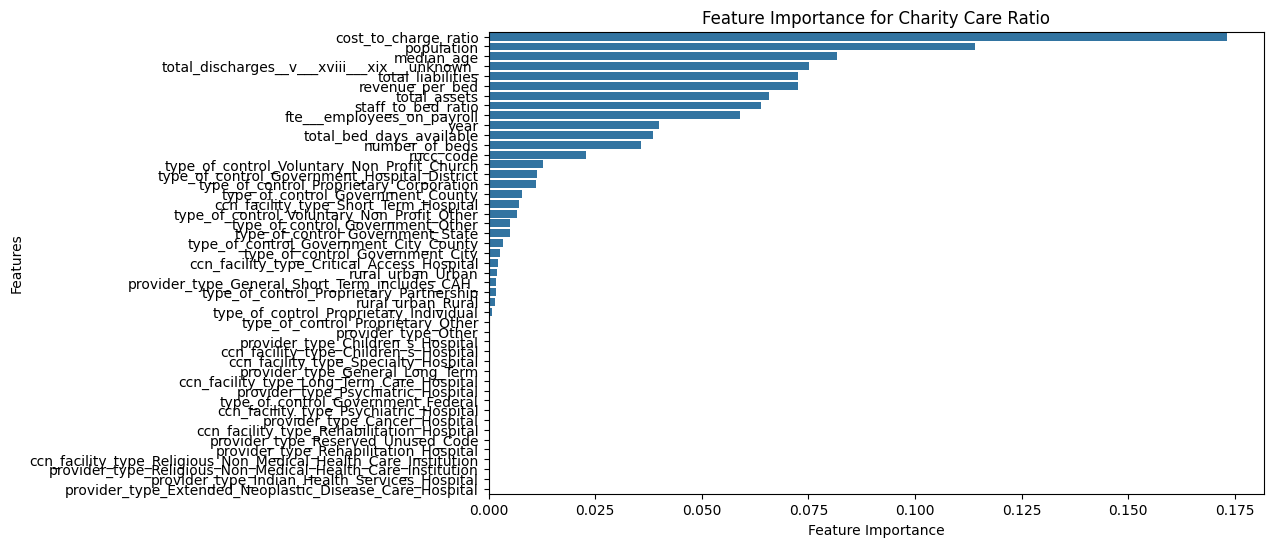

In [40]:
# Feature Importances for Charity Care Ratio
feature_importances = pd.Series(rf_charity.feature_importances_, index=X_train_ccr_encoded.columns)
feature_importances = feature_importances.sort_values(ascending=False)
# Plot the Importances
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_importances.index)
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance for Charity Care Ratio')
plt.show()

In [41]:
feature_importances.head(20)

cost_to_charge_ratio                            0.173075
population                                      0.114010
median_age                                      0.081761
total_discharges__v___xviii___xix___unknown_    0.075145
total_liabilities                               0.072677
revenue_per_bed                                 0.072537
total_assets                                    0.065713
staff_to_bed_ratio                              0.063784
fte___employees_on_payroll                      0.058953
year                                            0.039894
total_bed_days_available                        0.038504
number_of_beds                                  0.035868
rucc_code                                       0.022944
type_of_control_Voluntary_Non_Profit_Church     0.012756
type_of_control_Government_Hospital_District    0.011370
type_of_control_Proprietary_Corporation         0.011053
type_of_control_Government_County               0.007941
ccn_facility_type_Short_Term_Ho

## Run Advanced Models

In [22]:
!pip install xgboost
!pip install lightgbm



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.5 MB 3.8 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 4.7 MB/s  0:00:00



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

xgb_model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_pm_train_encoded, y_pm_train)

y_pm_pred_xgb = xgb_model.predict(X_pm_test_encoded)

print("Profit Margin XGBoost Test R²:",
      round(r2_score(y_pm_test, y_pm_pred_xgb), 3))

Profit Margin XGBoost Test R²: 0.493


In [24]:
import re

def clean_column_names(df):
    df.columns = [
        re.sub(r'[^A-Za-z0-9_]+', '_', col)
        for col in df.columns
    ]
    return df

X_pm_train_encoded = clean_column_names(X_pm_train_encoded)
X_pm_test_encoded = clean_column_names(X_pm_test_encoded)

In [25]:
from lightgbm import LGBMRegressor

lgb_model = LGBMRegressor(
    n_estimators=800,
    learning_rate=0.03,
    num_leaves=31,
    random_state=42
)

lgb_model.fit(X_pm_train_encoded, y_pm_train)

print("Profit Margin LightGBM Test R²:",
      round(lgb_model.score(X_pm_test_encoded, y_pm_test), 3))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002417 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2886
[LightGBM] [Info] Number of data points in the train set: 55644, number of used features: 44
[LightGBM] [Info] Start training from score 0.039422
Profit Margin LightGBM Test R²: 0.509


In [26]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_pm_train_encoded, y_pm_train)

print("Profit Margin Ridge Test R²:",
      round(ridge_model.score(X_pm_test_encoded, y_pm_test), 3))

Profit Margin Ridge Test R²: 0.136


c:\Users\manju\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.15468e-23): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


## Charity Care Ratio Advanced Models

In [27]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

xgb_charity = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1,
    random_state=42
)

xgb_charity.fit(X_train_ccr_encoded, y_train_ccr)

y_pred_xgb_ccr = xgb_charity.predict(X_test_ccr_encoded)

print("Charity Care XGBoost Test R²:",
      round(r2_score(y_test_ccr, y_pred_xgb_ccr), 3))

Charity Care XGBoost Test R²: 0.498


In [28]:
import re

def clean_column_names(df):
    df.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', col) for col in df.columns]
    return df

X_train_ccr_encoded = clean_column_names(X_train_ccr_encoded)
X_test_ccr_encoded = clean_column_names(X_test_ccr_encoded)

In [29]:
from lightgbm import LGBMRegressor

lgb_charity = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    random_state=42
)

lgb_charity.fit(X_train_ccr_encoded, y_train_ccr)

print("Charity Care LightGBM Test R²:",
      round(lgb_charity.score(X_test_ccr_encoded, y_test_ccr), 3))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002413 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2889
[LightGBM] [Info] Number of data points in the train set: 55644, number of used features: 44
[LightGBM] [Info] Start training from score 0.025628
Charity Care LightGBM Test R²: 0.479
